In [8]:
1626**2 + 47**2

2646085

['Sample in Buffer', 'Sample in Window', 'TRIGGER', 'rx_data_valid', 'rx_data_I[11:0]', 'user_probe_0[4:0]', 'rx_data_Q[11:0]', 'user_probe_1[4:0]', 'valid', 'bit_out[2:0]', 'phase_out[10:0]', 'tx_data_I[11:0]', 'tx_data_Q[11:0]', 'delta_out[2:0]', 'out_i[11:0]', 'out_q[11:0]', 'bit_in[2:0]', 'bit_in_d1[2:0]', 'data_in_int[13:0]']


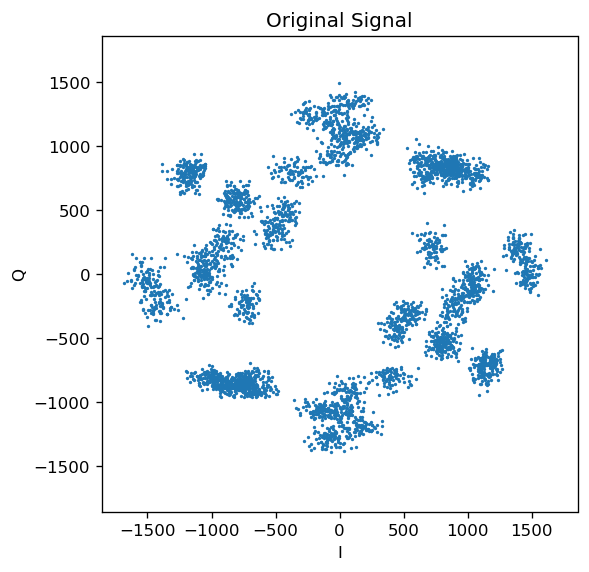

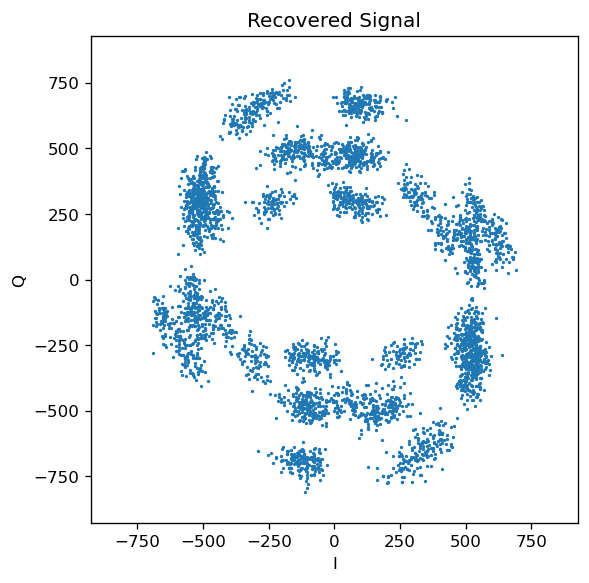

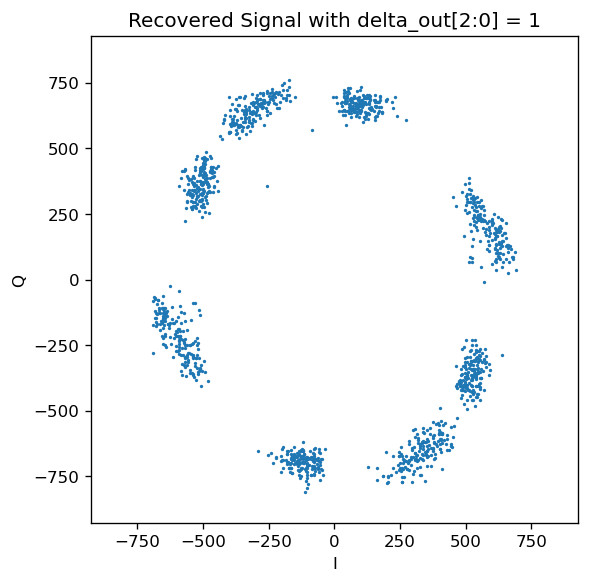

d:\Environments\anaconda\Lib\site-packages\numpy\fft\_pocketfft.py:70: ComplexWarning: Casting complex values to real discards the imaginary part
  r = pfi.execute(a, is_real, is_forward, fct)


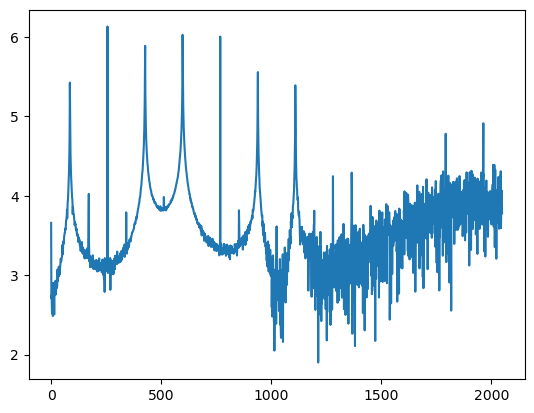

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_name = "iladata.csv"
df = pd.read_csv(file_name)

print(df.columns.to_list())
# ['Sample in Buffer', 'Sample in Window', 'TRIGGER', 'rx_data_valid', 'rx_data_I[11:0]', 'user_probe_0[4:0]', 'rx_data_Q[11:0]', 'user_probe_1[4:0]', 'valid', 'bit_out[2:0]', 'phase_out[10:0]', 'tx_data_I[11:0]', 'tx_data_Q[11:0]', 'delta_out[2:0]', 'out_i[11:0]', 'out_q[11:0]', 'bit_in[2:0]', 'bit_in_d1[2:0]', 'data_in_int[13:0]']

df = df.drop(index=0).loc[:, ["rx_data_valid", "rx_data_I[11:0]", "rx_data_Q[11:0]", "out_i[11:0]", "out_q[11:0]", "valid", "delta_out[2:0]"]].astype(int)
df = df.where(df["rx_data_valid"] == 1).dropna().reset_index(drop=True).drop(columns=["rx_data_valid"]).astype(int)
df.head()

x = np.arange(len(df))
# plt.figure(figsize=(18, 4))
# plt.step(x, df["rx_data_I[11:0]"], label="rx_data_I[11:0]")
# plt.step(x, df["rx_data_Q[11:0]"], label="rx_data_Q[11:0]")
# plt.xlim(0, 200)
# plt.legend()
# plt.show()

# plt.figure(figsize=(18, 4))
# plt.step(x, df["out_i[11:0]"], label="out_i[11:0]")
# plt.step(x, df["out_q[11:0]"], label="out_q[11:0]")
# plt.xlim(0, 200)
# plt.legend()
# plt.show()


# 补码
def get_twos_complement(array, bits):
    return np.where(array >= 0, array, (1 << bits) + array)


sample_width = 12

real = get_twos_complement(df["rx_data_I[11:0]"], sample_width)
imag = get_twos_complement(df["rx_data_Q[11:0]"], sample_width)

np.savetxt("./tb/tx_signal.hex", real * 2**sample_width + imag, fmt="%X")

real = df["rx_data_I[11:0]"]
imag = df["rx_data_Q[11:0]"]

def plot_star(signal, title="Star Diagram"):
    fig, ax = plt.subplots(figsize=(5,5), dpi=120)
    ax.plot(np.real(signal), np.imag(signal), ".", markersize=2)
    
    max_val = np.max(np.abs(signal)) * 1.1
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.set_title(title)
    
    ax.set_aspect("equal", adjustable="box")  # ✅ 坐标轴固定1:1
    
    fig.tight_layout()
    plt.show()


plot_star(real + 1j * imag, "Original Signal")
real2 = df["out_i[11:0]"]
imag2 = df["out_q[11:0]"]
plot_star(real2 + 1j * imag2, "Recovered Signal")

# 选取valid为1的点
df_valid = df.where(df["valid"] == 1).dropna().reset_index(drop=True)
real3 = df_valid["out_i[11:0]"]
imag3 = df_valid["out_q[11:0]"]
plot_star(real3 + 1j * imag3, "Recovered Signal with delta_out[2:0] = 1")

# 计算df['rx_data_I[11:0]']频谱
plt.plot(np.log10(np.abs(np.fft.rfft(real + 1j*imag))))
plt.show()

In [ ]:
# error rate
delta_out = df.where(df["valid"] == 1)["delta_out[2:0]"].dropna().astype(int).to_list()
error_count = 0
last = 7
for i in range(len(delta_out)):
    new = delta_out[i]
    # print((new - last) % 8)
    if (new - last) % 8 != 1:
        error_count += 1
    last = new

print(f"Total: {len(delta_out)}, Error: {error_count}, Error Rate: {error_count / len(delta_out):.2%}")

Total: 1365, Error: 3, Error Rate: 0.22%
